# **Install required libraries**

In [1]:
!pip install -q diffusers transformers accelerate safetensors gdown pyngrok fastapi uvicorn pillow

^C
ERROR: Operation cancelled by user


# **Download your LoRA model from Google Drive**

In [2]:
import gdown

url = "https://drive.google.com/uc?id=1eLSUDSVVVHM5pGmAK94B9BRJtjwzFLZM"
output = "brandybot_lora.safetensors"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1eLSUDSVVVHM5pGmAK94B9BRJtjwzFLZM
From (redirected): https://drive.google.com/uc?id=1eLSUDSVVVHM5pGmAK94B9BRJtjwzFLZM&confirm=t&uuid=61548568-b58f-4a22-9031-533fcb46ffb7
To: /kaggle/working/brandybot_lora.safetensors
100%|██████████| 743M/743M [00:05<00:00, 141MB/s]  


'brandybot_lora.safetensors'

**Verify**

In [3]:
!ls -lh

total 709M
-rw-r--r-- 1 root root 709M Jan  3 12:25 brandybot_lora.safetensors


# **Load SDXL base model + your LoRA**

In [4]:
import torch
from diffusers import StableDiffusionXLPipeline

base_model = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    base_model,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

# Load your trained LoRA
pipe.load_lora_weights(
    ".",
    weight_name="brandybot_lora.safetensors"
)

pipe.fuse_lora()

print("✅ SDXL + LoRA loaded successfully")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ SDXL + LoRA loaded successfully


# **Test image generation**

Token indices sequence length is longer than the specified maximum sequence length for this model (162 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['visual balance high contrast composition on a dark background sharp geometric shapes and smooth edges sleek modern typography integrated with the symbol technology - driven and enterprise - level aesthetic elegant and powerful visual tone neon glow highlights without overpowering the design centered logo composition, symmetrical and balanced scalable logo design suitable for websites, apps, and billboards no complex background, logo - focused composition professional branding mockup quality ultra high resolution, crisp details high quality, modern logo generation']
Token indices sequence length is longer than the specified maximum sequence length for this model (162 > 77). Running this sequence through th

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


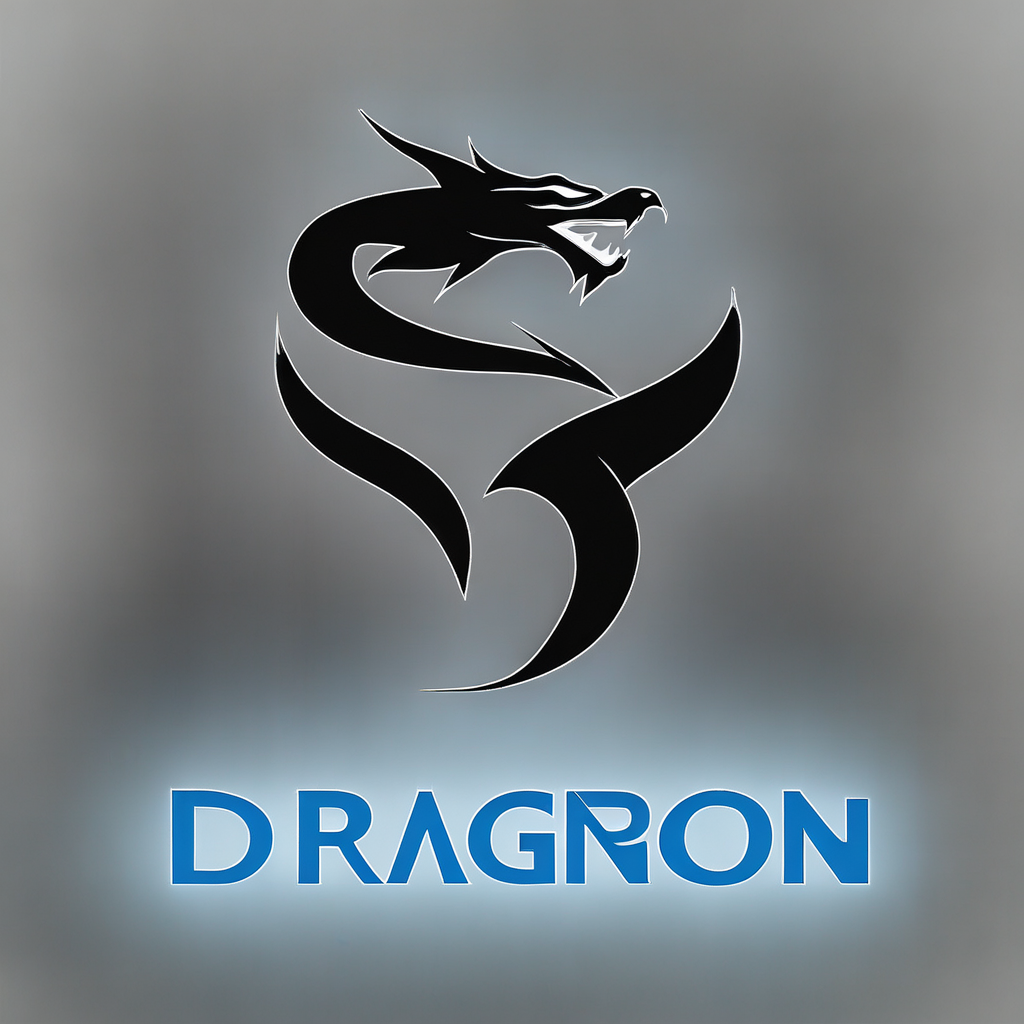

In [5]:
prompt1 = "modern minimal logo for a tech startup, flat vector style, brand identity"
negative_prompt1 = "blurry, low quality, watermark, text"

prompt = "A high-end professional logo design for a brand named 'Dragon Group' Futuristic and premium corporate brand identity Primary color palette of neon blue and deep black Secondary accents using subtle electric blue glow A stylized dragon symbol representing strength, leadership, and innovation Modern abstract dragon form, not cartoon or fantasy style Clean flat vector logo suitable for digital and print branding Minimal and bold design with strong visual balance High contrast composition on a dark background Sharp geometric shapes and smooth edges Sleek modern typography integrated with the symbol Technology-driven and enterprise-level aesthetic Elegant and powerful visual tone Neon glow highlights without overpowering the design Centered logo composition, symmetrical and balanced Scalable logo design suitable for websites, apps, and billboards No complex background, logo-focused composition Professional branding mockup quality Ultra high resolution, crisp details High quality, modern logo generation" 
negative_prompt = "low quality, blurry, pixelated, watermark, extra text, cartoon, anime, fantasy illustration, photorealistic, busy background, noisy, distorted, sketch, hand-drawn"

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

image

# **Create FastAPI app (API layer)**

In [15]:
# 1. Install missing dependencies (Required every time you restart Kaggle)
!pip install -q pyngrok fastapi uvicorn

import torch
import base64
from io import BytesIO
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from pyngrok import ngrok
import uvicorn

# 2. Setup FastAPI
app = FastAPI()

@app.post("/generate")
async def generate(prompt: str):
    try:
        # Generate exactly 2 images using your 'pipe'
        # num_images_per_prompt=2 generates variants simultaneously
        results = pipe(
            prompt, 
            num_images_per_prompt=2, 
            num_inference_steps=30, 
            guidance_scale=7.5,
            width=512, 
            height=512
        ).images
        
        images_base64 = []
        for img in results:
            buffered = BytesIO()
            img.save(buffered, format="PNG")
            img_str = base64.b64encode(buffered.getvalue()).decode()
            images_base64.append(img_str)
        
        return {"images_base64": images_base64}
    except Exception as e:
        print(f"Error generating images: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))

# 3. Start Ngrok Tunnel
# IMPORTANT: If you have an Ngrok Auth Token, uncomment the line below and add it:
# ngrok.set_auth_token("YOUR_AUTH_TOKEN_HERE")

# Close any existing tunnels to avoid "Too many sessions" error
ngrok.kill()


# **Run the server inside Kaggle (threaded)**

In [16]:
import torch
import base64
from io import BytesIO
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from pyngrok import ngrok
import uvicorn
import nest_asyncio

# 1. Allow nested event loops (Required for running uvicorn inside Jupyter)
nest_asyncio.apply()

# 2. Setup FastAPI
app = FastAPI()

@app.get("/")
async def root():
    return {"status": "online", "model": "SDXL + LoRA"}

@app.post("/generate")
async def generate(prompt: str):
    """
    Generates exactly 2 logo variants.
    Expects prompt as a query parameter: /generate?prompt=...
    """
    try:
        print(f"🎨 Generating for prompt: {prompt}")
        
        # Generate exactly 2 images using the 'pipe' defined in previous cells
        # width/height reduced to 512 for faster results in testing
        results = pipe(
            prompt, 
            num_images_per_prompt=2, 
            num_inference_steps=30, 
            guidance_scale=7.5,
            width=512, 
            height=512
        ).images
        
        images_base64 = []
        for img in results:
            buffered = BytesIO()
            img.save(buffered, format="PNG")
            img_str = base64.b64encode(buffered.getvalue()).decode()
            images_base64.append(img_str)
        
        print(f"✅ Generated {len(images_base64)} images.")
        return {"images_base64": images_base64}
        
    except Exception as e:
        print(f"❌ Error generating images: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))

# 3. Start Ngrok Tunnel
# Close any existing tunnels to avoid "Too many sessions" error
ngrok.kill()

# Set your auth token (Keep this secure!)
NGROK_TOKEN = "3AC4OMDhZggzkUXG1avfWPPNuak_7haVP7CCJQH3cAfUa33Eg"
ngrok.set_auth_token(NGROK_TOKEN)

# Connect Ngrok to port 8000
public_url = ngrok.connect(8000).public_url

print("\n" + "="*50)
print(f"🚀 YOUR AI SERVICE IS LIVE AT:")
print(f"🔗 {public_url}")
print("="*50 + "\n")

# 4. Run the Server
# This will keep the cell running. Do not stop it while using the app.
uvicorn.run(app, host="0.0.0.0", port=8000)


🚀 YOUR AI SERVICE IS LIVE AT:
🔗 https://eda-morphological-irrefutably.ngrok-free.dev



RuntimeError: asyncio.run() cannot be called from a running event loop